# Module 4 — Initial knowledge stock `N0`

Every other model parameter is fixed by the empirical fits of Module 2; `N0`
is not. This notebook compiles the model, runs it over a grid of `N0` values
for **both datasets**, and scores each run against the empirical trajectory by
the combined log-RMSE on novelties `D` and explorers `D_w`. It then re-runs the
best `N0` of each dataset and keeps those simulation files on disk, which is
what Module 5 reduces and Module 6 plots.

Requires the trajectory cache built by `module_3_trajectories.ipynb`.

**Outputs** — into `sim_runs/<dataset>/`: `n0_grid_results.csv` (one row per
run, versioned), `best_n0_run.json` (the selected run, versioned) and, under
`data_simulations/`, the trajectory of the best run only. Every other
trajectory is deleted right after it is scored: the full set would be hundreds
of GB.


In [1]:
# Repository bootstrap.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

OUTPUT_DIR = REPO_ROOT / "outputs"
TRAJECTORY_DIR = OUTPUT_DIR / "trajectories"   # built by module_3_trajectories
MODEL_SRC_DIR = REPO_ROOT                      # the C source lives at the repository root
RUN_DIR = REPO_ROOT / "sim_runs"

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from plot_style import apply_paper_style, PAPER_COLORS

apply_paper_style(grid=True)
colors = list(PAPER_COLORS)

from analysis_utils import (
    compile_model_binary,
    run_and_score_model_grid,
    run_model_simulation,
)
from utils import annual_summary, load_all_trajectories

pd.set_option("display.max_columns", 60)


## Configuration

`MODEL_PARAMS` holds the calibration from the empirical fits of Module 2. Its
`N0` entry is only a starting point and is overridden by every value of the
grid. `N0_GRIDS` is a coarse scan plus a refinement in steps of 500 around the
best-performing region.


In [2]:
DATASETS = ['patents', 'papers']
filter_empty_keywords = True
verbose_logs = False

MODEL_PARAMS = {
    'patents': {'T': 41, 'nu': 1.0, 'rho': 1.0, 'N0': 120000,
                'a': 0.0545, 'b': 1.33, 'w0': 269781},
    'papers': {'T': 41, 'nu': 1.0, 'rho': 1.0, 'N0': 13000,
               'a': 0.167, 'b': 0.71, 'w0': 212313},
}

N0_GRIDS = {
    'patents': np.concatenate([
        np.array([70000, 80000, 90000]),
        np.arange(95000, 105001, 500),
        np.array([120000, 130000, 140000, 150000, 160000]),
    ]),
    'papers': np.concatenate([
        np.array([10000, 40000]),
        np.arange(45000, 55000, 500),
        np.array([60000, 70000, 80000]),
    ]),
}

FIT_START_YEAR = {'patents': 1980, 'papers': 1980}


## Compile the model and load the empirical targets


In [3]:
binary_path = compile_model_binary(MODEL_SRC_DIR)

trajectories = load_all_trajectories(
    TRAJECTORY_DIR,
    filter_empty_keywords=filter_empty_keywords,
)
empirical = {
    name: {
        'annual': annual_summary(trajectories[name]),
        'intrinsic': trajectories[name].df[['t', 'D', 'Dw']],
    }
    for name in DATASETS
}
display(pd.DataFrame([{
    'dataset': name,
    'events': trajectories[name].n,
    'years': f"{int(empirical[name]['annual']['year'].min())}"
             f"-{int(empirical[name]['annual']['year'].max())}",
} for name in DATASETS]))


[model] compiling: gcc -O3 -std=gnu11 model_micro_macro.c -lm -o model_micro_macro (cwd=.)


,dataset,events,years
0,patents,1431653,1980-2020
1,papers,5193236,1980-2020


## Scan the grid and select `N0`, for both datasets

One run per `N0`, scored against the empirical series, then a final re-run of
the winner which is the one kept on disk.


In [4]:
scans = {}
best = {}

for dataset in DATASETS:
    print(f"\n{'=' * 70}\n{dataset}\n{'=' * 70}")
    results_dir = RUN_DIR / dataset
    base_params = MODEL_PARAMS[dataset].copy()

    results_df = run_and_score_model_grid(
        binary_path=binary_path,
        workdir=results_dir,
        base_params=base_params,
        N0_values=N0_GRIDS[dataset],
        empirical_annual=empirical[dataset]['annual'],
        empirical_intrinsic=empirical[dataset]['intrinsic'],
        intrinsic_points=5000,
        start_year=FIT_START_YEAR[dataset],
        combined_columns=('D', 'Dw'),
        cleanup_outputs=True,
        save_results_csv=results_dir / 'n0_grid_results.csv',
        verbose=verbose_logs,
    )
    scans[dataset] = results_df.sort_values('N0').reset_index(drop=True)

    best_row = results_df.sort_values('rmse_log_total').iloc[0]
    best_params = base_params.copy()
    best_params['N0'] = int(best_row['N0'])

    best_run = run_model_simulation(
        binary_path=binary_path,
        workdir=results_dir,
        T=int(best_params['T']),
        nu=float(best_params['nu']),
        rho=float(best_params['rho']),
        N0=int(best_params['N0']),
        a=float(best_params['a']),
        b=float(best_params['b']),
        w0=float(best_params['w0']),
        verbose=verbose_logs,
    )

    summary = {
        'dataset': dataset,
        'best_N0': int(best_params['N0']),
        'rmse_D': float(best_row['rmse_D']),
        'rmse_Dw': float(best_row['rmse_Dw']),
        'rmse_log_total': float(best_row['rmse_log_total']),
        # Recorded relative to the repository root: this file is versioned.
        'trajectory_path': str(Path(best_run['trajectory']).relative_to(REPO_ROOT)),
        'frequency_path': str(Path(best_run['frequency']).relative_to(REPO_ROOT)),
        'params': {k: (int(v) if k in ('T', 'N0') else float(v))
                   for k, v in best_params.items()},
    }
    (results_dir / 'best_n0_run.json').write_text(json.dumps(summary, indent=2))
    best[dataset] = summary
    print(f"{dataset}: best N0 = {summary['best_N0']:,}")

display(pd.DataFrame([
    {'dataset': d, 'best_N0': b['best_N0'], 'rmse_log_total': b['rmse_log_total'],
     'grid points': len(scans[d])}
    for d, b in best.items()
]))



patents
[model] running: ./model_micro_macro 41 1.0 1.0 70000 0.0545 1.33 269781.0 (cwd=./sim_runs/patents)


[model] finished N0=70000 | combined log-RMSE=0.072633
[model] running: ./model_micro_macro 41 1.0 1.0 80000 0.0545 1.33 269781.0 (cwd=./sim_runs/patents)


[model] finished N0=80000 | combined log-RMSE=0.068974
[model] running: ./model_micro_macro 41 1.0 1.0 90000 0.0545 1.33 269781.0 (cwd=./sim_runs/patents)


[model] finished N0=90000 | combined log-RMSE=0.067004
[model] running: ./model_micro_macro 41 1.0 1.0 95000 0.0545 1.33 269781.0 (cwd=./sim_runs/patents)


[model] finished N0=95000 | combined log-RMSE=0.066321
[model] running: ./model_micro_macro 41 1.0 1.0 95500 0.0545 1.33 269781.0 (cwd=./sim_runs/patents)


...

[model] finished N0=60000 | combined log-RMSE=0.089943
[model] running: ./model_micro_macro 41 1.0 1.0 70000 0.167 0.71 212313.0 (cwd=./sim_runs/papers)


[model] finished N0=70000 | combined log-RMSE=0.098920
[model] running: ./model_micro_macro 41 1.0 1.0 80000 0.167 0.71 212313.0 (cwd=./sim_runs/papers)


[model] finished N0=80000 | combined log-RMSE=0.109115
[model] saved grid results to ./sim_runs/papers/n0_grid_results.csv
[model] running: ./model_micro_macro 41 1.0 1.0 49000 0.167 0.71 212313.0 (cwd=./sim_runs/papers)


papers: best N0 = 49,000


,dataset,best_N0,rmse_log_total,grid points
0,patents,100500,0.066109,29
1,papers,49000,0.085634,25


## Diagnostic plot

A quick check that the minimum is well defined. The publication version of
this panel is `si_n0_sensitivity.ipynb`, which reads the same scan.


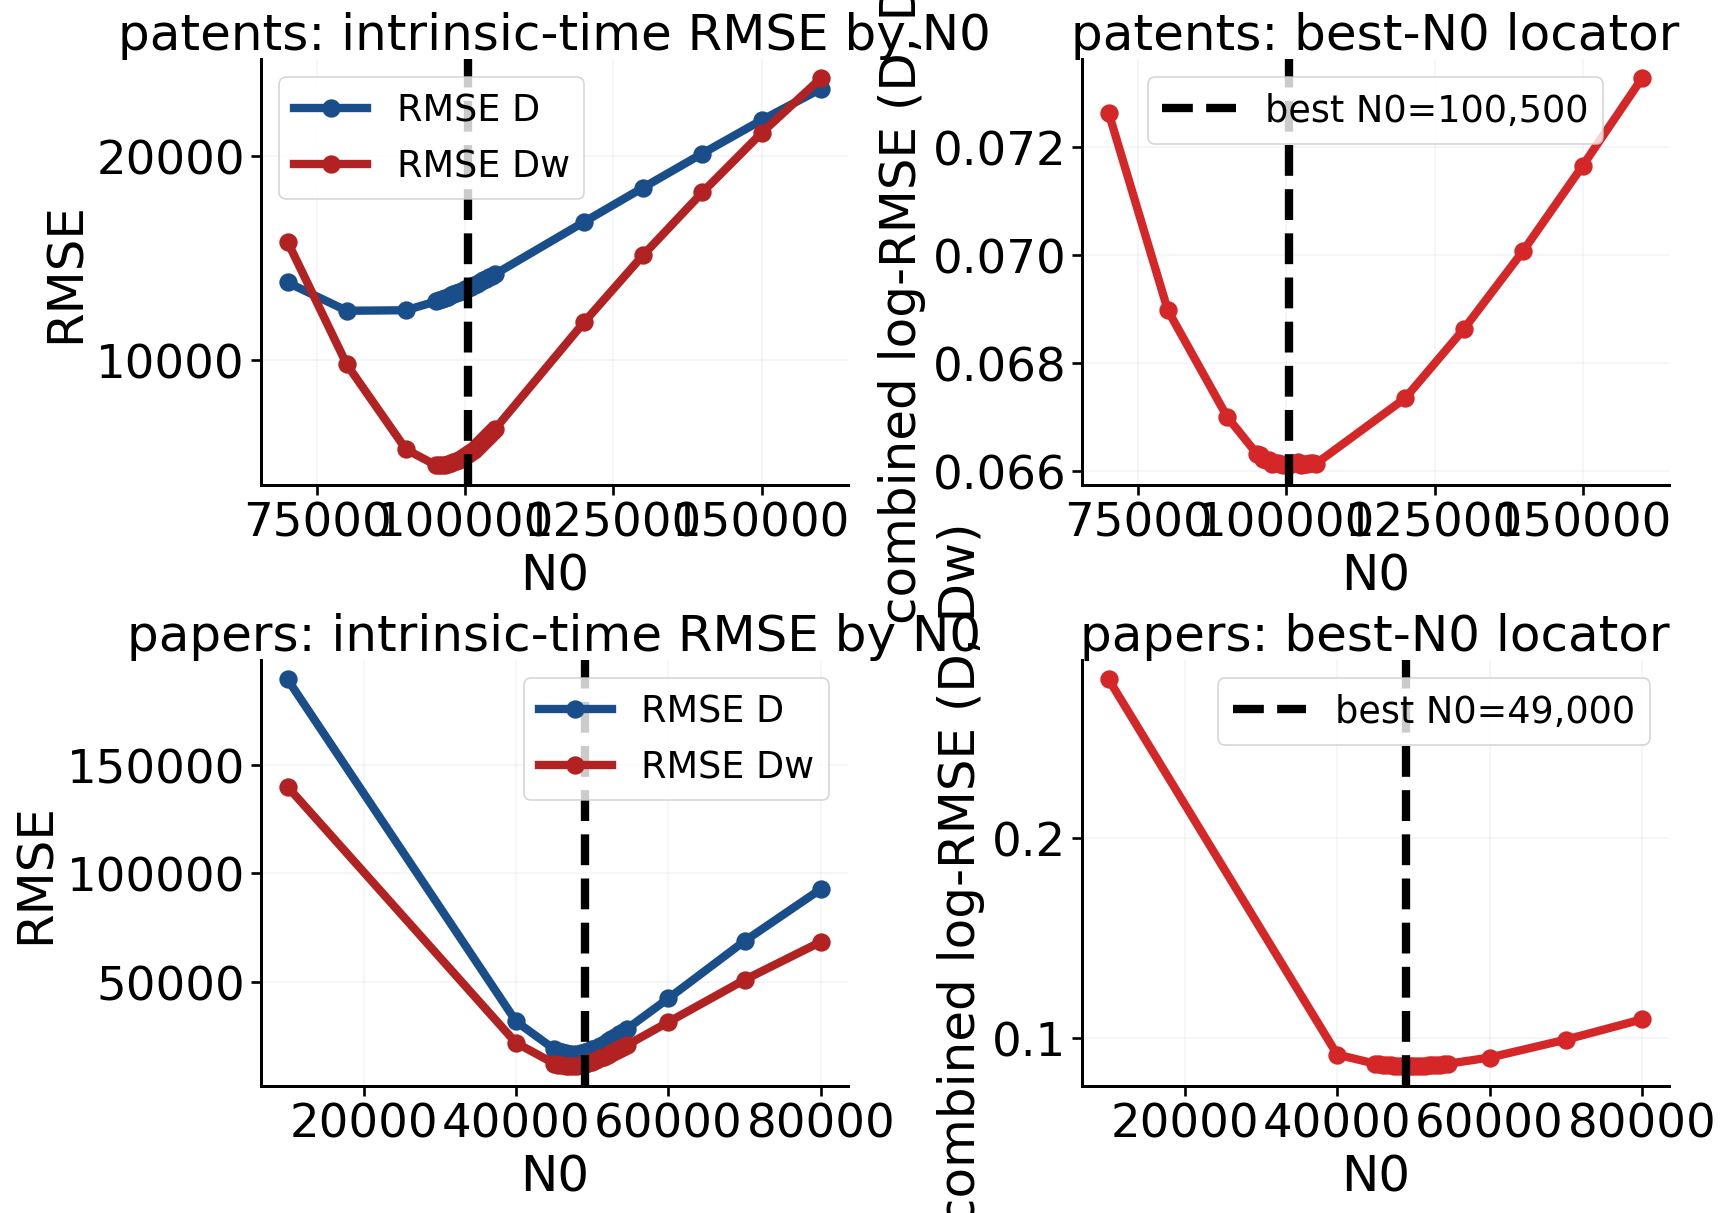

In [5]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 5 * len(DATASETS)),
                         constrained_layout=True, squeeze=False)

for row, dataset in enumerate(DATASETS):
    scan = scans[dataset]
    best_N0 = best[dataset]['best_N0']

    ax = axes[row, 0]
    ax.plot(scan['N0'], scan['rmse_D'], 'o-', label='RMSE D')
    ax.plot(scan['N0'], scan['rmse_Dw'], 'o-', label='RMSE Dw')
    ax.axvline(best_N0, color='black', ls='--')
    ax.set_xlabel('N0')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{dataset}: intrinsic-time RMSE by N0')
    ax.legend()

    ax = axes[row, 1]
    ax.plot(scan['N0'], scan['rmse_log_total'], 'o-', color='tab:red')
    ax.axvline(best_N0, color='black', ls='--', label=f'best N0={best_N0:,}')
    ax.set_xlabel('N0')
    ax.set_ylabel('combined log-RMSE (D, Dw)')
    ax.set_title(f'{dataset}: best-N0 locator')
    ax.legend()

plt.show()
